In [ ]:
TITANIC EXPLORATORY DATA ANALYSIS

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("train (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


DataSet

In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age Group

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [12]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [13]:
df.drop(columns=["Cabin"], inplace=True)

In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df["AgeGroup"] = pd.cut (
    df["Age"],
    bins = [0, 12, 18, 30, 50, 80],
    labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


Survival Rate by Age Group



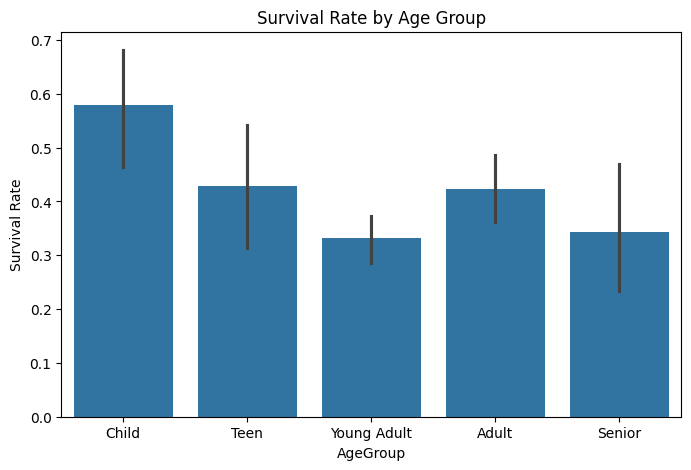

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="AgeGroup", y="Survived")
plt.title("Survival Rate by Age Group")
plt.xlabel
plt.ylabel("Survival Rate")
plt.show()

Survival Rate by Embarkation Port

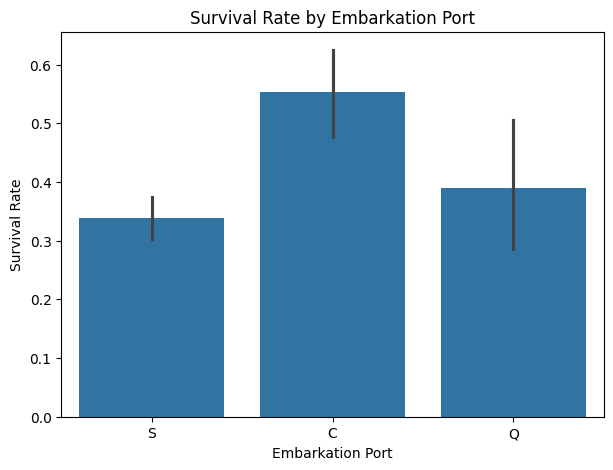

In [17]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="Embarked", y="Survived")
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")
plt.show()

Family Size


In [18]:
df["FamilySize"] = df["SibSp"] + df["Parch"]
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


Survival Rate by family Size

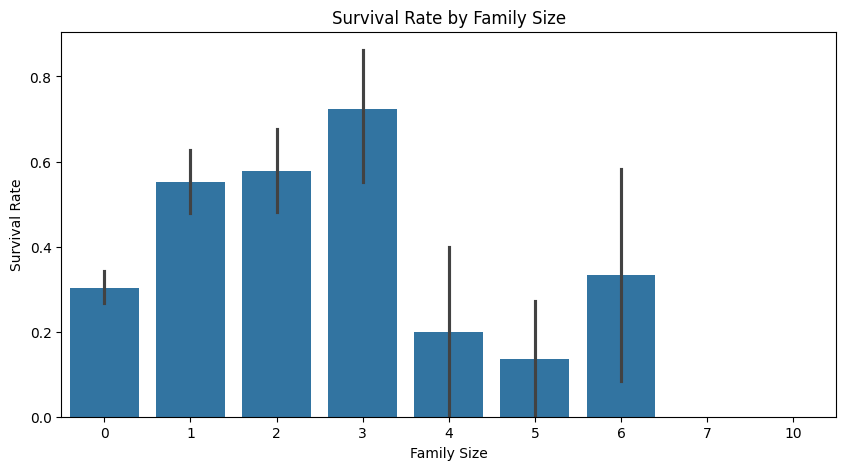

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(data=df, x="FamilySize", y="Survived")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

Age Distribution

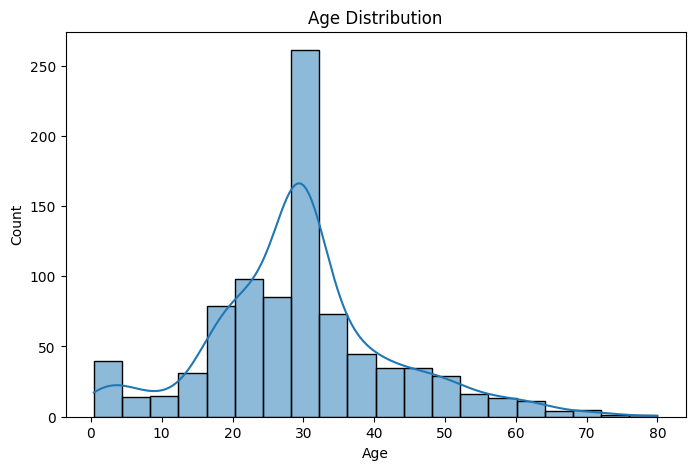

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Correlation Heatmap

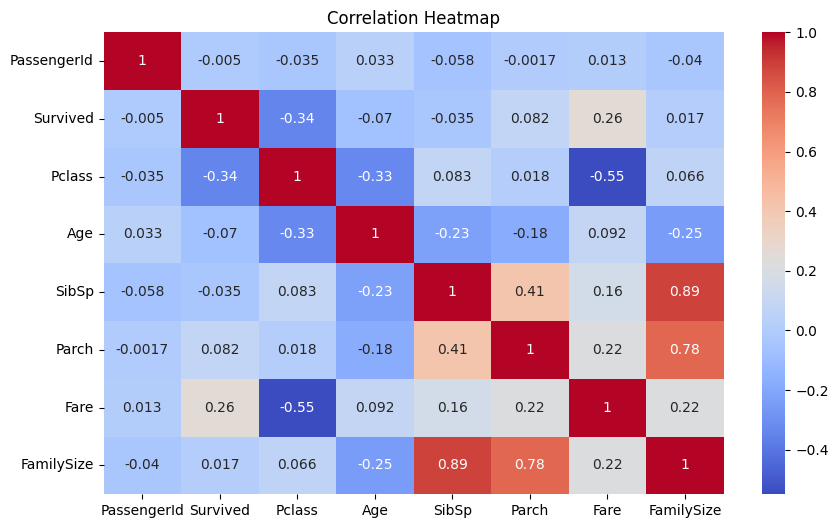

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Conclusion

The Titanic dataset was successfully cleaned and analyzed using Python. Missing values were handled, new features were created, and exploratory data analysis (EDA) was performed. Visualizations helped understand how age, family size, and embarkation port affected passenger survival.